# AutoValue — Model Pipeline and Model Selection

## Objective

In the previous modelling notebook, I progressively evaluated different regression feature sets and established the strongest linear-regression configuration.

The best-performing linear model used:

- mileage
- vehicle age
- manufacturer

This notebook converts the experimental workflow into a reusable scikit-learn preprocessing and modelling pipeline.

I will:

- recreate the modelling dataset
- define numerical and categorical features
- build a reusable preprocessing pipeline
- reproduce the strongest linear-regression result
- compare additional regression models
- visualize model performance
- analyze prediction errors
- select a final candidate model for deployment

## 1. Imports

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder
from sklearn.linear_model import LinearRegression

from sklearn.metrics import (
    mean_absolute_error,
    mean_squared_error,
    r2_score
)

## 2. Load and Prepare the Modelling Dataset

I load the original vehicle dataset and apply the modelling-scope decisions established during exploratory analysis.

AutoValue v1 focuses on the mainstream used-car market, with listing prices between **$1,000 and $100,000**.

Rows with missing mileage are removed because mileage is an important predictor and only a very small proportion of the dataset is affected.

I also create `vehicle_age` from the original model year.

In [2]:
df = pd.read_csv("../data/raw/cars.csv")

In [3]:
MIN_PRICE = 1_000
MAX_PRICE = 100_000
REFERENCE_YEAR = 2024

clean_df = df[
    (df["price"] >= MIN_PRICE) &
    (df["price"] <= MAX_PRICE)
].copy()

clean_df = clean_df.dropna(
    subset=["mileage"]
).copy()

clean_df["vehicle_age"] = (
    REFERENCE_YEAR - clean_df["year"]
)

In [4]:
print("Original rows:", len(df))
print("Modelling rows:", len(clean_df))

clean_df[
    ["manufacturer", "year", "vehicle_age", "mileage", "price"]
].head()

Original rows: 762091
Modelling rows: 751667


,manufacturer,year,vehicle_age,mileage,price
0,Acura,2013,11,92945.0,13988.0
1,Acura,2013,11,47645.0,17995.0
2,Acura,2013,11,53422.0,17000.0
3,Acura,2013,11,117598.0,14958.0
4,Acura,2013,11,114865.0,14498.0


## 3. Define Features and Target

The strongest linear-regression experiment used mileage, vehicle age, and manufacturer.

I use the same feature set here so that the pipeline implementation can be directly compared with the previous experiment.

In [5]:
features = [
    "mileage",
    "vehicle_age",
    "manufacturer"
]

X = clean_df[features]
y = clean_df["price"]

In [6]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42
)

print("Training:", X_train.shape)
print("Testing:", X_test.shape)

Training: (601333, 3)
Testing: (150334, 3)


In [7]:
print("Model 3 clean_df shape:", clean_df.shape)
print("Rows:", len(clean_df))

print(
    clean_df[
        ["price", "mileage", "vehicle_age"]
    ].describe()
)

Model 3 clean_df shape: (751667, 21)
Rows: 751667
               price       mileage    vehicle_age
count  751667.000000  7.516670e+05  751667.000000
mean    30943.576066  5.636078e+04       6.218742
std     16505.112675  4.349438e+04       5.011073
min      1000.000000  0.000000e+00       0.000000
25%     19495.000000  2.397800e+04       3.000000
50%     27795.000000  4.623600e+04       5.000000
75%     38950.000000  7.895600e+04       8.000000
max    100000.000000  1.119067e+06     109.000000


In [8]:
print("Pipeline training rows:", len(X_train))
print("Pipeline test rows:", len(X_test))

print("Train target mean:", y_train.mean())
print("Test target mean:", y_test.mean())

Pipeline training rows: 601333
Pipeline test rows: 150334
Train target mean: 30956.846214992358
Test target mean: 30890.495736160814


## 4. Build the Preprocessing Pipeline

The modelling dataset contains both numerical and categorical features.

Numerical features can be passed directly to the regression model, while `manufacturer` must first be converted into a numerical representation.

I use a `ColumnTransformer` to apply different preprocessing steps to different feature types:

- numerical features are passed through unchanged
- manufacturer is one-hot encoded
- the fitted preprocessing is learned from the training data only

This preprocessing is then combined with the regression model inside a single scikit-learn `Pipeline`.

In [10]:
numeric_features = [
    "mileage",
    "vehicle_age"
]

categorical_features = [
    "manufacturer"
]

In [16]:
preprocessor = ColumnTransformer(
    transformers=[
        (
            "numerical",
            "passthrough",
            numeric_features
        ),
        (
            "categorical",
            OneHotEncoder(
                handle_unknown="ignore",
                drop="first",
                sparse_output=False
            ),
            categorical_features
        )
    ]
)

In [17]:
linear_pipeline = Pipeline(
    steps=[
        ("preprocessing", preprocessor),
        ("model", LinearRegression())
    ]
)

In [18]:
linear_pipeline.fit(
    X_train,
    y_train
)

,"steps steps: list of tuplesList of (name of step, estimator) tuples that are to be chained insequential order. To be compatible with the scikit-learn API, all stepsmust define `fit`. All non-last steps must also define `transform`. See:ref:`Combining Estimators <combining_estimators>` for more details.","[('preprocessing', ...), ('model', ...)]"
,"transform_input transform_input: list of str, default=NoneThe names of the :term:`metadata` parameters that should be transformed by thepipeline before passing it to the step consuming it.This enables transforming some input arguments to ``fit`` (other than ``X``)to be transformed by the steps of the pipeline up to the step which requiresthem. Requirement is defined via :ref:`metadata routing <metadata_routing>`.For instance, this can be used to pass a validation set through the pipeline.You can only set this if metadata routing is enabled, which youcan enable using ``sklearn.set_config(enable_metadata_routing=True)``... versionadded:: 1.6",None
,"memory memory: str or object with the joblib.Memory interface, default=NoneUsed to cache the fitted transformers of the pipeline. The last stepwill never be cached, even if it is a transformer. By default, nocaching is performed. If a string is given, it is the path to thecaching directory. Enabling caching triggers a clone of the transformersbefore fitting. Therefore, the transformer instance given to thepipeline cannot be inspected directly. Use the attribute ``named_steps``or ``steps`` to inspect estimators within the pipeline. Caching thetransformers is advantageous when fitting is time consuming. See:ref:`sphx_glr_auto_examples_neighbors_plot_caching_nearest_neighbors.py`for an example on how to enable caching.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each step will be printed as itis completed.",False
Name,Type,Value
"feature_names_in_ feature_names_in_: ndarray of shape (`n_features_in_`,)Names of features seen during :term:`fit`. Only defined if theunderlying estimator exposes such an attribute when fit... versionadded:: 1.0","ndarray[object](3,)","['mileage','vehicle_age','manufacturer']"
n_features_in_ n_features_in_: intNumber of features seen during :term:`fit`. Only defined if theunderlying first estimator in `steps` exposes such an attributewhen fit... versionadded:: 0.24,int,3
,"transformers transformers: list of tuplesList of (name, transformer, columns) tuples specifying thetransformer objects to be applied to subsets of the data.name : str Like in Pipeline and FeatureUnion, this allows the transformer and its parameters to be set using ``set_params`` and searched in grid search.transformer : {'drop', 'passthrough'} or estimator Estimator must support :term:`fit` and :term:`transform`. Special-cased strings 'drop' and 'passthrough' are accepted as well, to indicate to drop the columns or to pass them through untransformed, respectively.columns : str, array-like of str, int, array-like of int, array-like of bool, slice or callable Indexes the data on its second axis. Integers are interpreted as positional columns, while strings can reference DataFrame columns by name. A scalar string or int should be used where ``transformer`` expects X to be a 1d array-like (vector), otherwise a 2d array will be passed to the transformer. A callable is passed the input data `X` and can return any of the above. To select multiple columns by name or dtype, you can use :obj:`make_column_selector`.","[('numerical', ...), ('categorical', ...)]"
,"remainder remainder: {'drop', 'passthrough'} or estimator, default='drop'By default, only the specified columns in `transformers` aretransformed and combined in the output, and the non-specifiedcolumns are dropped. (default of ``'drop'``).By specifying ``remainder='passthrough'``, all remaining columns thatwere not specified in `transformers`, but present in the data passedto `fit` will be automatically passed through. This subset of columnsis concatenated wi

In [19]:
y_pred_linear = linear_pipeline.predict(
    X_test
)

## 5. Pipeline Linear Regression Evaluation

I evaluate the pipeline implementation using the same MAE, RMSE, and R² metrics used in the earlier experiments.

Because this pipeline uses the same features as the strongest previous linear-regression model, I expect its performance to closely reproduce the earlier result.

In [20]:
mae_linear = mean_absolute_error(
    y_test,
    y_pred_linear
)

rmse_linear = np.sqrt(
    mean_squared_error(
        y_test,
        y_pred_linear
    )
)

r2_linear = r2_score(
    y_test,
    y_pred_linear
)

print("Pipeline Linear MAE: $", round(mae_linear, 2))
print("Pipeline Linear RMSE: $", round(rmse_linear, 2))
print("Pipeline Linear R²:", round(r2_linear, 4))

Pipeline Linear MAE: $ 8547.31
Pipeline Linear RMSE: $ 11802.52
Pipeline Linear R²: 0.4874


## 6. Visualizing Baseline Predictions

Evaluation metrics summarize overall model performance, but they do not show how predictions behave across individual vehicle listings.

I therefore compare the actual vehicle prices with the prices predicted by the linear-regression pipeline.

For a well-performing regression model, predictions should lie close to the diagonal line where predicted price equals actual price.

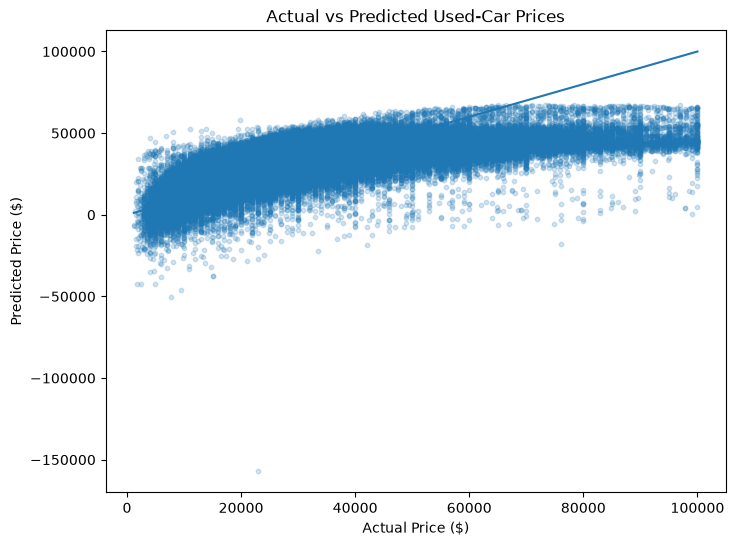

In [21]:
plt.figure(figsize=(8, 6))

plt.scatter(
    y_test,
    y_pred_linear,
    alpha=0.2,
    s=10
)

plt.plot(
    [y_test.min(), y_test.max()],
    [y_test.min(), y_test.max()]
)

plt.xlabel("Actual Price ($)")
plt.ylabel("Predicted Price ($)")
plt.title("Actual vs Predicted Used-Car Prices")

plt.show()

### Interpretation

The actual-versus-predicted plot reveals limitations of the linear-regression baseline.

Although predictions generally increase with actual vehicle prices, they do not closely follow the ideal diagonal relationship. The model particularly tends to underpredict vehicles at the higher end of the price range.

Some predictions are also negative, which is not meaningful for vehicle prices. This occurs because ordinary linear regression does not constrain its predictions to realistic price boundaries.

The systematic pattern in the prediction errors suggests that vehicle price is not fully explained by a simple additive linear relationship between mileage, vehicle age, and manufacturer.

This motivates evaluating nonlinear regression models that can capture more complex relationships and interactions between vehicle characteristics.